<a href="https://colab.research.google.com/github/froyglezzz/Quimica-Cuantica/blob/main/Actividad_Molecula_H_Li.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mólecula de hidruro de litio (LiH) usando qiskit

In [1]:
!pip install "qiskit==1.2.4" \
"qiskit-nature==0.7.2" \
"qiskit-aer==0.15.1" \
"qiskit-algorithms==0.3.1" \
pyscf \
matplotlib \
numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/310.5 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 12.4 MB/s eta 0:00:00


In [2]:
# Nombre: s10_molecula_26
# Objetivo: calcula las energías al variar la separación de dos atomos
#primero importamos lo necesario
import numpy as np
import pylab
from qiskit import *
from qiskit_aer.primitives import Sampler
from qiskit_algorithms.optimizers import SLSQP
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_nature.second_q.mappers import JordanWignerMapper
import matplotlib.pyplot as plt

In [3]:
#Definimos nuestra molécula considerando una posición variable
molecule = 'H .0 .0 -{0}; Li .0 .0 {0}'
# Probamos para una distancia
d = 0.5
#driver = PySCFDriver(molecule.format(d/2),basis='sto3g')
driver = PySCFDriver(molecule.format(d/2), basis='STO-6G')
qmolecule = driver.run()
#aplicamos el hamiltoniano
hamiltonian = qmolecule.hamiltonian
#obtenemos la energia de repulsión
repulsion = hamiltonian.nuclear_repulsion_energy
#ahora obtenemos el valor de la energía del estado base
solver = GroundStateEigensolver(
JordanWignerMapper(),
NumPyMinimumEigensolver(),
)
result = solver.solve(qmolecule)
base = result.total_energies[0]
print('Energia estado base:' , base)
print('Energía de repulsión: ', repulsion)
print(result)

Energia estado base: -7.139465466844493
Energía de repulsión:  3.1750632655200004
=== GROUND STATE ENERGY ===
 
* Electronic ground state energy (Hartree): -10.314528732364
  - computed part:      -10.314528732364
~ Nuclear repulsion energy (Hartree): 3.17506326552
> Total ground state energy (Hartree): -7.139465466844
 
=== MEASURED OBSERVABLES ===
 
  0:  # Particles: 4.000 S: 0.000 S^2: 0.000 M: 0.000
 
=== DIPOLE MOMENTS ===
 
~ Nuclear dipole moment (a.u.): [0.0  0.0  0.94486306]
 
  0: 
  * Electronic dipole moment (a.u.): [0.0  0.0  -1.138432757497]
    - computed part:      [0.0  0.0  -1.138432757497]
  > Dipole moment (a.u.): [0.0  0.0  2.083295817497]  Total: 2.083295817497
                 (debye): [0.0  0.0  5.295209292296]  Total: 5.295209292296
 


In [5]:
#Tambien definimos nuestro rango y paso de análisis de distancias
distancias = np.arange(0.3,4.0,0.1)
#Definimos nuestros vectores de almacenamiento
repulsiones = []
bases = []
#Con el ciclo vamos a ir variando la distancia y midiendo los valores
#de energía de repulción y energia del estado base
for i,d in enumerate(distancias):
  print('step',i)
#algunas veces es necesario instalar el driver pueden hacerlo con:
# pip install --prefer-binary pyscf
#driver = PySCFDriver(molecule.format(d),basis='sto3g')
  driver = PySCFDriver(molecule.format(d/2), basis='STO-6G')
  qmolecule = driver.run()
  hamiltonian = qmolecule.hamiltonian
  repulsion = hamiltonian.nuclear_repulsion_energy
  repulsiones.append(repulsion)
  solver = GroundStateEigensolver(
  JordanWignerMapper(),
  NumPyMinimumEigensolver(),
  )
  result = solver.solve(qmolecule)
  base = result.total_energies[0]
  bases.append(base)
  #imprimimos las energias
  print('Distancia: ', d)
  print('Energía de repulsión: ', repulsion)
  print('Energia estado base:' , base)

step 0
Distancia:  0.3
Energía de repulsión:  5.2917721092
Energia estado base: -5.973316751407378
step 1
Distancia:  0.4
Energía de repulsión:  3.9688290819
Energia estado base: -6.727030739488293
step 2
Distancia:  0.5
Energía de repulsión:  3.1750632655200004
Energia estado base: -7.139465466844534
step 3
Distancia:  0.6000000000000001
Energía de repulsión:  2.6458860546
Energia estado base: -7.410885835855105
step 4
Distancia:  0.7000000000000002
Energía de repulsión:  2.2679023325142853
Energia estado base: -7.597126658827724
step 5
Distancia:  0.8000000000000003
Energía de repulsión:  1.9844145409499996
Energia estado base: -7.725985544735875
step 6
Distancia:  0.9000000000000001
Energía de repulsión:  1.7639240364
Energia estado base: -7.814884068691367
step 7
Distancia:  1.0000000000000002
Energía de repulsión:  1.5875316327599998
Energia estado base: -7.875652564927922
step 8
Distancia:  1.1000000000000003
Energía de repulsión:  1.443210575236363
Energia estado base: -7.916516

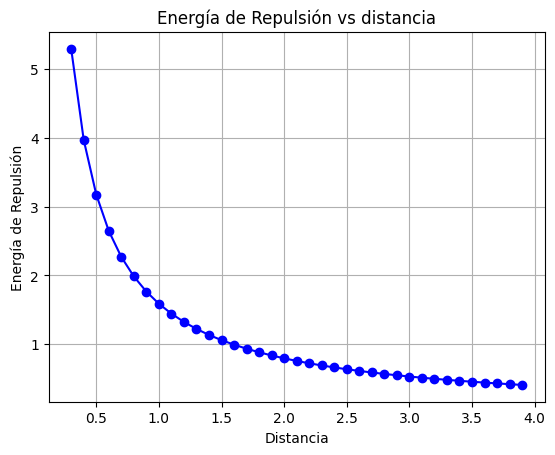

In [6]:
# graficamos las energías de repulsión
plt.plot(distancias, repulsiones, marker='o', linestyle='-', color='b')
plt.title('Energía de Repulsión vs distancia')
plt.xlabel('Distancia')
plt.ylabel('Energía de Repulsión')
plt.grid(True)
plt.show()

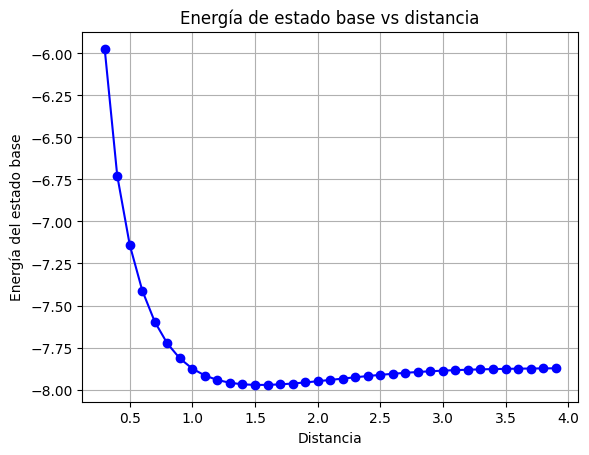

In [7]:
#graficamos las energías del estado base
plt.plot(distancias, bases, marker='o', linestyle='-', color='b')
plt.title('Energía de estado base vs distancia')
plt.xlabel('Distancia')
plt.ylabel('Energía del estado base')
plt.grid(True)
plt.show()